# Cartographie des défaillances par chapitre ATA

## Objectif de ce notebook

Première vraie analyse du projet : **quels systèmes de l'avion (chapitres ATA) génèrent le plus de signalements de maintenance ?**

On regarde ça sous deux angles différents, qui répondent à deux questions différentes — volontairement, pas juste l'un des deux :

1. **Où est le volume ?** (comptage brut, diagramme de Pareto) — utile pour savoir où se concentre la charge de travail de maintenance.
2. **Quel chapitre est signalé plus que ce à quoi on s'attendrait, une fois qu'on tient compte de la taille de chaque flotte ?** (taux normalisé) — utile pour comparer les familles entre elles sans que "il y a plus d'A320 en service" fausse la lecture.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sdr_analytics import config
from sdr_analytics.metrics import pareto_table, taux_pour_1000_avions

pd.set_option("display.max_columns", 100)

df = pd.read_parquet(config.CHEMIN_DONNEES_TRAITEES / "sdr_airbus_clean.parquet")
print(f"{len(df)} lignes chargées")

140139 lignes chargées


## 1. Filtrer sur le périmètre de l'analyse

On garde seulement les familles A320/A330/A350 (`dans_perimetre`), et seulement les années complètes (2026 exclue, elle fausserait toute comparaison par année).

In [2]:
df_perimetre = df[df["dans_perimetre"] & df["annee_complete"]].copy()
print(f"{len(df_perimetre)} lignes dans le périmètre (A320/A330/A350, années 2015-2025)")
df_perimetre["famille_appareil"].value_counts()

112195 lignes dans le périmètre (A320/A330/A350, années 2015-2025)


famille_appareil
A320    97794
A330    13742
A350      659
Name: count, dtype: int64

## 2. Où se concentre le volume ? (comptage brut, Pareto)

On compte le nombre de signalements par chapitre ATA, toutes familles confondues, et on trie du plus fréquent au moins fréquent.

In [3]:
comptage_brut = df_perimetre.groupby("chapitre_ata").size()
pareto = pareto_table(comptage_brut)

# On rattache le libellé compréhensible du chapitre pour l'affichage
libelles = df_perimetre[["chapitre_ata", "libelle_ata"]].drop_duplicates().set_index("chapitre_ata")
pareto = pareto.join(libelles)

pareto.head(15)

,nb_signalements,part_pct,part_cumulee_pct,libelle_ata
chapitre_ata,,,,
53,33785,30.112750,30.112750,Fuselage
33,17002,15.153973,45.266723,Éclairage
52,13909,12.397166,57.663889,Portes
25,11184,9.968359,67.632247,Équipements et aménagements
21,6637,5.915593,73.547841,Climatisation
55,5039,4.491287,78.039128,Empennages
57,4933,4.396809,82.435937,Voilure (ailes)
32,2227,1.984937,84.420874,Train d'atterrissage
49,2019,1.799545,86.220420,Groupe auxiliaire de puissance (APU)


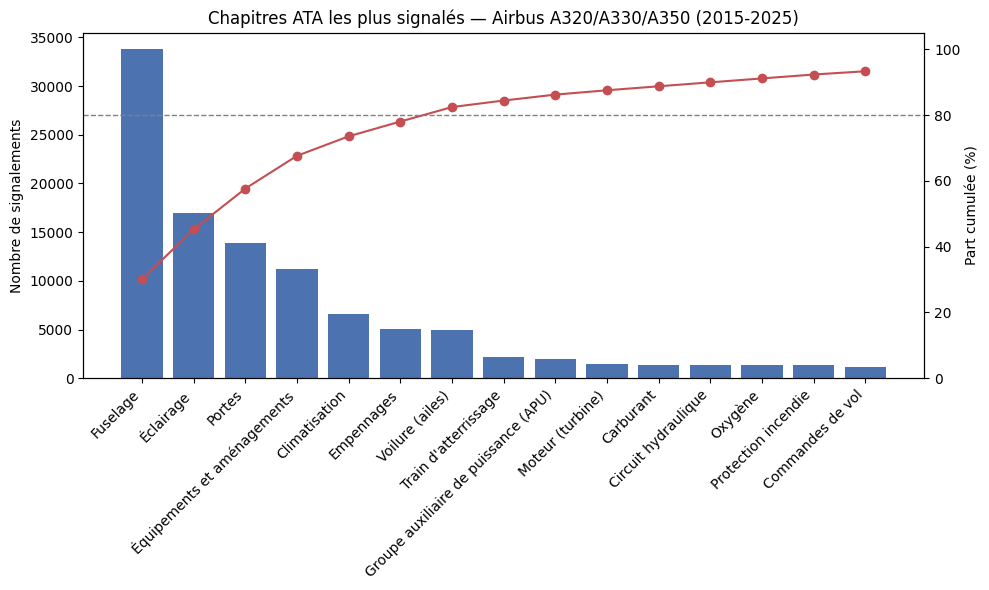

In [4]:
top15 = pareto.head(15)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(top15["libelle_ata"], top15["nb_signalements"], color="#4C72B0")
ax1.set_ylabel("Nombre de signalements")
ax1.set_xticks(range(len(top15)))
ax1.set_xticklabels(top15["libelle_ata"], rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(top15["libelle_ata"], top15["part_cumulee_pct"], color="#C44E52", marker="o")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Part cumulée (%)")
ax2.set_ylim(0, 105)

plt.title("Chapitres ATA les plus signalés — Airbus A320/A330/A350 (2015-2025)")
fig.tight_layout()
plt.show()

**Comment lire ce graphique** : les barres bleues sont le nombre de signalements par chapitre, du plus fréquent au moins fréquent. La ligne rouge est le pourcentage cumulé — elle montre combien de chapitres, à eux seuls, représentent 80% de tous les signalements (ligne pointillée grise). C'est la logique "règle des 80/20" : est-ce qu'une poignée de systèmes concentre l'essentiel de la charge de maintenance, ou est-ce que les problèmes sont répartis partout ?

## 3. Comparer les familles entre elles (taux normalisé)

Le comptage brut ne suffit pas pour comparer les familles : l'A320 est bien plus nombreux dans la flotte que l'A350, donc il aura mécaniquement plus de signalements, sans que ça veuille dire qu'il est "moins fiable". On calcule donc un taux : nombre de signalements pour 1000 avions distincts observés dans les données, par famille et par chapitre.

Ici, on compte les avions distincts sur l'ensemble de la période 2015-2025 (pas année par année), pour avoir une vision d'ensemble par famille.

In [5]:
avions_distincts_par_famille = df_perimetre.groupby("famille_appareil")["AircraftSerialNumber"].nunique()
print("Nombre d'avions distincts observés par famille (2015-2025) :")
avions_distincts_par_famille

Nombre d'avions distincts observés par famille (2015-2025) :


famille_appareil
A320    2568
A330     210
A350      41
Name: AircraftSerialNumber, dtype: int64

In [6]:
chapitres_a_afficher = top15.index.tolist()

comptage_croise = (
    df_perimetre[df_perimetre["chapitre_ata"].isin(chapitres_a_afficher)]
    .groupby(["chapitre_ata", "famille_appareil"])
    .size()
    .rename("nb_signalements")
    .reset_index()
)
comptage_croise["nb_avions_distincts"] = comptage_croise["famille_appareil"].map(avions_distincts_par_famille)
comptage_croise["taux_pour_1000_avions"] = taux_pour_1000_avions(
    comptage_croise["nb_signalements"], comptage_croise["nb_avions_distincts"]
)

tableau_taux = comptage_croise.pivot(index="chapitre_ata", columns="famille_appareil", values="taux_pour_1000_avions")
tableau_taux = tableau_taux.reindex(chapitres_a_afficher)  # garder l'ordre du Pareto
tableau_taux.index = tableau_taux.index.map(libelles["libelle_ata"])

tableau_taux.round(1)

famille_appareil,A320,A330,A350
chapitre_ata,,,
Fuselage,11166.7,24047.6,1439.0
Éclairage,5570.9,11928.6,4658.5
Portes,4764.8,7700.0,1365.9
Équipements et aménagements,4025.3,3861.9,878.0
Climatisation,2435.4,1742.9,414.6
Empennages,1917.4,376.2,878.0
Voilure (ailes),1744.2,1695.2,2390.2
Train d'atterrissage,777.3,1019.0,414.6
Groupe auxiliaire de puissance (APU),678.7,1304.8,48.8


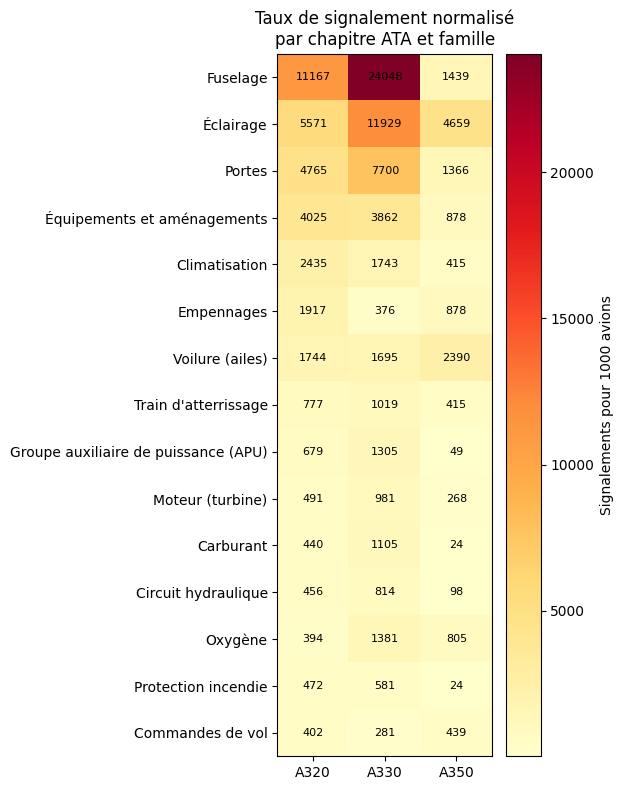

In [7]:
fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(tableau_taux.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(tableau_taux.columns)))
ax.set_xticklabels(tableau_taux.columns)
ax.set_yticks(range(len(tableau_taux.index)))
ax.set_yticklabels(tableau_taux.index)

for i in range(tableau_taux.shape[0]):
    for j in range(tableau_taux.shape[1]):
        valeur = tableau_taux.values[i, j]
        if not np.isnan(valeur):
            ax.text(j, i, f"{valeur:.0f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, label="Signalements pour 1000 avions")
plt.title("Taux de signalement normalisé\npar chapitre ATA et famille")
plt.tight_layout()
plt.show()

**Rappel important** : ce taux n'est pas un vrai taux de panne. Le dénominateur (avions distincts *observés dans les signalements*) sous-estime la vraie taille de flotte, puisqu'un avion sans aucun problème signalé n'apparaît jamais dans ces données. C'est un indicateur de comparaison relative entre familles, pas une mesure absolue de fiabilité.

## 4. Exporter les résultats pour le dashboard

On sauvegarde le comptage complet chapitre × famille × année — il sera réutilisé tel quel dans le dashboard et dans le notebook de tendance temporelle (bloc 4), pour ne pas refaire ce calcul deux fois.

In [8]:
agg_complet = (
    df_perimetre.groupby(["chapitre_ata", "libelle_ata", "famille_appareil", "AnneeFichier"])
    .size()
    .rename("nb_signalements")
    .reset_index()
)

agg_complet.to_parquet(config.CHEMIN_DONNEES_TRAITEES / "agg_ata_famille_annee.parquet", index=False)
print(f"Exporté : {len(agg_complet)} lignes -> data/processed/agg_ata_famille_annee.parquet")

Exporté : 864 lignes -> data/processed/agg_ata_famille_annee.parquet


## Ce qu'on retient

- **Le volume de signalements est très concentré** : un seul chapitre (Fuselage) représente à lui seul 30% de tous les signalements A320/A330/A350. Les 7 premiers chapitres (Fuselage, Éclairage, Portes, Équipements/aménagements, Climatisation, Empennages, Voilure) totalisent 82% du volume — la règle des 80/20 se vérifie presque exactement ici.
- **Le taux normalisé raconte une histoire différente du comptage brut** : par exemple, l'A330 a un taux de signalement "Fuselage" nettement plus élevé que l'A320 une fois ramené à sa taille de flotte (≈24 000 vs ≈11 200 pour 1000 avions), alors qu'en comptage brut l'A320 domine largement (parce qu'il y a beaucoup plus d'A320 en service).
- **Prudence sur A330 et surtout A350** : ces taux reposent sur un nombre d'avions distincts bien plus faible (210 pour l'A330, seulement 41 pour l'A350, contre 2 568 pour l'A320) — donc plus sensibles au bruit statistique. Un seul avion avec beaucoup de signalements peut faire bouger le taux de façon disproportionnée pour ces familles. À garder en tête avant de tirer une conclusion trop ferme sur l'A350 en particulier.

*(Ces points seront repris dans `docs/methodologie_limites.md` une fois tous les blocs d'analyse construits.)*